In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
from sc_flow.backends.torch import probability_paths
from sc_flow import SCFlow
from sc_flow.dataset.toy_data import get_toy_dataset

In [ ]:
# create dataset
adata = get_toy_dataset("moons", noise=0.1).adata

# register data and initialize model
SCFlow.register_adata(adata)
model = SCFlow(
    method_id="csm",
    vf_decoder_mlp_kwargs={
        "hidden_dims": [
            32,
            32,
        ]
    },
    device_id="cpu",
    time_features_id="torch-cfm",
    conditioning_id="resnet1d",
    # probability_path=probability_paths.LinearGaussianProbabilityPath(.2)
    probability_path=probability_paths.SchrodingerBridgeProbabilityPath(0.2),
    # probability_path=probability_paths.VariancePreservingDiracProbabilityPath(0.)
    # probability_path=probability_paths.LinearDiracProbabilityPath()
)

# train model
model.train(adata, n_train_steps=50_000, optim_kwargs={"lr": 1e-4})

100%|██████████| 1/1 [00:00<00:00, 12985.46it/s]
| loss:0.2617 | step:30599:  61%|██████▏   | 30628/50000 [00:32<00:20, 930.27it/s]


KeyboardInterrupt: 

<Axes: xlabel='step'>

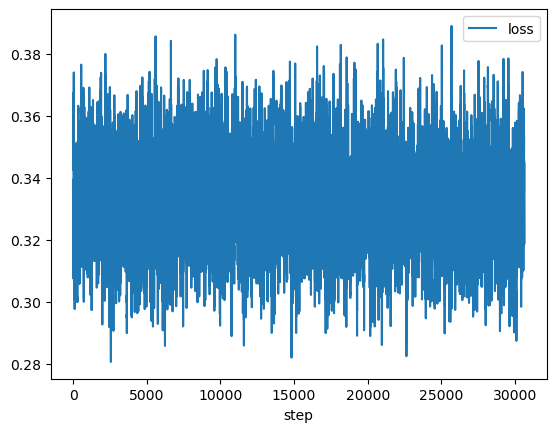

In [31]:
train_logs = model.trainer.get_train_logs_df()
train_logs_smooth = train_logs.ewm(alpha=0.1).mean()
train_logs_smooth.plot()

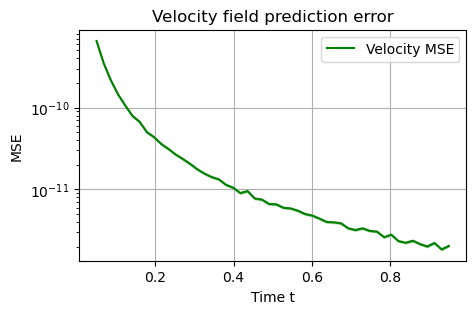

In [ ]:
def evaluate_velocity_mse(model, adata, n_samples=1024, n_t=20, n_batches=5, eps=1e-6):
    """Compute MSE between true conditional velocity and predicted velocity derived from the score network."""
    device = model._method._device_id
    path = model._method._probability_path
    sigma = path._sigma

    t_grid = np.linspace(0.05, 0.95, n_t)
    all_vel_mse = []

    for _ in range(n_batches):
        idx = np.random.choice(adata.n_obs, n_samples, replace=False)
        target = torch.from_numpy(adata.X[idx]).float().to(device)
        source = torch.randn_like(target).to(device)

        vel_losses = []
        for t_val in t_grid:
            t = torch.full((n_samples,), t_val, device=device, dtype=torch.float32)

            # Compute interpolant and coefficients
            x_t = path.compute_xt(t, source, target)
            alpha = path.compute_alpha_t(t) if hasattr(path, "compute_alpha_t") else t
            alpha_dot = path.compute_dot_alpha_t(t) if hasattr(path, "compute_dot_alpha_t") else torch.ones_like(t)
            sigma_dot = path.compute_dot_sigma_t(t)

            # True conditional velocity
            u_true = path.compute_ut(t, x_t, source, target)

            # Predicted velocity from score network
            with torch.no_grad():
                st = model._method._module(t, x_t, condition_dict={}, source=source)

            # Velocity formula derived from score: v = (α̇/α)*(x - source) + (ασ̇ - α̇σ)/α * st * σ
            alpha_safe = alpha + eps
            vt_base = (alpha_dot / alpha_safe)[..., None] * (x_t - source)
            coef = (alpha * sigma_dot - alpha_dot * sigma) / alpha_safe
            vt_pred = vt_base + (coef[..., None] * st) * sigma  # note: st * sigma
            # Confirm: DenoiserVelocity uses coef * st, where coef = σ(ασ̇ - α̇σ)/α,
            # so vt = vt_base + coef * st, which is equivalent to the above.

            # Compute MSE between true and predicted velocity
            vel_mse = torch.nn.functional.mse_loss(vt_pred, u_true).item()
            vel_losses.append(vel_mse)

        all_vel_mse.append(vel_losses)

    mean_vel_mse = np.mean(all_vel_mse, axis=0)
    std_vel_mse = np.std(all_vel_mse, axis=0)
    return t_grid, mean_vel_mse, std_vel_mse


# Run the diagnostic
t_grid, mean_vel_mse, std_vel_mse = evaluate_velocity_mse(model, adata, n_samples=1000, n_t=50, n_batches=10, eps=1e-6)

# Plot velocity MSE
plt.figure(figsize=(5, 3))
plt.plot(t_grid, mean_vel_mse, "g-", label="Velocity MSE")
plt.fill_between(t_grid, mean_vel_mse - std_vel_mse, mean_vel_mse + std_vel_mse, alpha=0.3, color="green")
plt.xlabel("Time t")
plt.ylabel("MSE")
plt.title("Velocity field prediction error")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

Predicting: 100%|██████████| 1/1 [00:00<00:00,  9.00it/s]

t=tensor(1.0000e-07) -> coef=tensor(0.)
t=tensor(1.0000e-07) -> coef_base=tensor(10.)
t=tensor(0.0101) -> coef=tensor(0.)
t=tensor(0.0101) -> coef_base=tensor(10.)
t=tensor(0.0202) -> coef=tensor(0.)
t=tensor(0.0202) -> coef_base=tensor(10.)
t=tensor(0.0303) -> coef=tensor(0.)
t=tensor(0.0303) -> coef_base=tensor(10.)
t=tensor(0.0404) -> coef=tensor(0.)
t=tensor(0.0404) -> coef_base=tensor(10.)
t=tensor(0.0505) -> coef=tensor(0.)
t=tensor(0.0505) -> coef_base=tensor(10.)
t=tensor(0.0606) -> coef=tensor(0.)
t=tensor(0.0606) -> coef_base=tensor(10.)
t=tensor(0.0707) -> coef=tensor(0.)
t=tensor(0.0707) -> coef_base=tensor(10.)
t=tensor(0.0808) -> coef=tensor(0.)
t=tensor(0.0808) -> coef_base=tensor(10.)
t=tensor(0.0909) -> coef=tensor(0.)
t=tensor(0.0909) -> coef_base=tensor(10.)
t=tensor(0.1010) -> coef=tensor(0.)
t=tensor(0.1010) -> coef_base=tensor(9.9000)
t=tensor(0.1111) -> coef=tensor(0.)
t=tensor(0.1111) -> coef_base=tensor(9.0000)
t=tensor(0.1212) -> coef=tensor(0.)
t=tensor(0.121

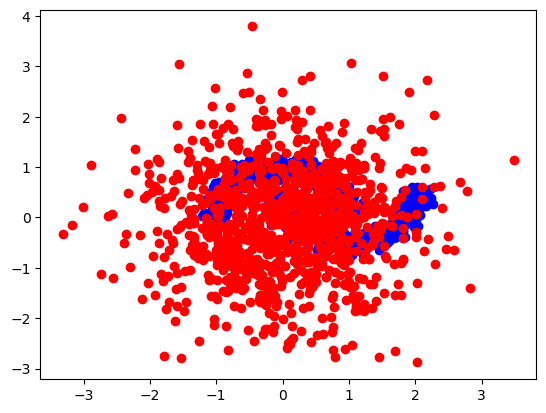

In [33]:
# predict
adata_pred = model.predict(
    adata,
    num_steps=100,
    solver_kwargs={"method": "euler"},  # , tau=1e-3, eps=1e-5, max_val=1.0
)

# visualize
plt.scatter(
    adata.X[:, 0],
    adata.X[:, 1],
    color="blue",
)
plt.scatter(adata_pred.X[:, 0], adata_pred.X[:, 1], color="red")